# Calcolo della f0 su tutto il dataset

In [185]:
import os
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from lib.readwav import readwav
import ipywidgets as widgets
import json
import emcee

In [186]:
%matplotlib widget
plt.close('all')

Abbiamo alcune opzioni da confrontare per il calcolo della f0, tra cui:
- primo picco dello spettro di potenza
- gcd approx
- regressione lineare
- bayesiano

In [187]:
def get_f0_first_peak(peak_freqs, freqs, spectrum):
    return peak_freqs[0] if len(peak_freqs) > 0 else None


def get_f0_from_gcd(peak_freqs):
    if len(peak_freqs) < 2:
        return None  # Non abbastanza picchi per calcolare la f0

    peak_freqs = peak_freqs[:5]

    fmin = np.min(peak_freqs) / 2
    fmax = np.min(peak_freqs)
    candidates = np.arange(fmin, fmax, 0.05)

    best_f0 = None
    best_score = float('inf')

    for f0 in candidates:
        residual = np.sum(np.abs((peak_freqs / f0) - np.round(peak_freqs / f0)))

        if residual < best_score and np.round(peak_freqs / f0).min() > 0:  # Assicurati che ci siano armoniche valide
            best_score = residual
            best_f0 = f0
    
    return best_f0

def get_f0_linear_regression(peak_freqs):

    peak_freqs = peak_freqs[:5]

    if len(peak_freqs) < 2:
        return None  # Non abbastanza picchi per la regressione lineare
    x = np.arange(1, len(peak_freqs) + 1)
    y = peak_freqs
    A = np.vstack([x, np.ones(len(x))]).T
    m, c = np.linalg.lstsq(A, y, rcond=None)[0]
    return m  # La pendenza della retta è la f0 stimata


"""
observed_freqs = np.asarray(freqs_channel1[peaks], dtype=float)



# Inizializzazione walker
ndim, nwalkers = 3, 50

f0_guess = np.min(observed_freqs)
sigma_guess = 10.0  # Hz

p0 = np.column_stack([
    np.random.normal(f0_guess, f0_guess * 0.8, nwalkers),
    np.random.normal(np.log(sigma_guess), 0.5, nwalkers),
    np.random.uniform(0.5, 1.0, nwalkers)
])

sampler = emcee.EnsembleSampler(
    nwalkers,
    ndim,
    log_prob_vect,
    vectorize=True,
)

state = sampler.run_mcmc(p0, 100000, progress=True)
"""

'\nobserved_freqs = np.asarray(freqs_channel1[peaks], dtype=float)\n\n\n\n# Inizializzazione walker\nndim, nwalkers = 3, 50\n\nf0_guess = np.min(observed_freqs)\nsigma_guess = 10.0  # Hz\n\np0 = np.column_stack([\n    np.random.normal(f0_guess, f0_guess * 0.8, nwalkers),\n    np.random.normal(np.log(sigma_guess), 0.5, nwalkers),\n    np.random.uniform(0.5, 1.0, nwalkers)\n])\n\nsampler = emcee.EnsembleSampler(\n    nwalkers,\n    ndim,\n    log_prob_vect,\n    vectorize=True,\n)\n\nstate = sampler.run_mcmc(p0, 100000, progress=True)\n'

In [188]:

def get_limiti_prior(observed_freqs):
    f_min = np.min(observed_freqs) / 2.0
    f_max = np.min(observed_freqs) * 1.2

    log_sigma_min = np.log(0.1)   # 0.1 Hz
    log_sigma_max = np.log(10)   # 10 Hz

    log_uniform = -np.log(f_max - f_min)

    ns_max = len(observed_freqs)

    return f_min, f_max, log_sigma_min, log_sigma_max, log_uniform


def init_bayesian(observed_freqs, nwalkers=50):
    f_min, f_max, log_sigma_min, log_sigma_max, log_uniform = get_limiti_prior(observed_freqs)

    n_max = len(observed_freqs)

    ns = np.arange(1, n_max + 1)

    log_norm_const = -0.5 * np.log(2.0 * np.pi)

    def log_prob_vect(theta_batch):
        theta_batch = np.atleast_2d(theta_batch)

        f0 = theta_batch[:, 0]
        log_sigma = theta_batch[:, 1]
        q = theta_batch[:, 2]

        logp = np.full(theta_batch.shape[0], -np.inf, dtype=float)

        valid = (
            (f0 > f_min) & (f0 < f_max) &
            (log_sigma > log_sigma_min) & (log_sigma < log_sigma_max) &
            (q > 0.0) & (q < 1.0)
        )

        if not np.any(valid):
            return logp

        f0v = f0[valid]
        log_sigmav = log_sigma[valid]
        qv = q[valid]

        sigma = np.exp(log_sigmav)

        # expected shape: (Wv, N)
        expected = f0v[:, None] * ns[None, :]

        # residuals shape: (Wv, K, N)
        residuals = observed_freqs[None, :, None] - expected[:, None, :]

        # log N(f_k | n f0, sigma^2), shape: (Wv, K, N)
        log_gauss = (
            -0.5 * (residuals / sigma[:, None, None]) ** 2
            - np.log(sigma)[:, None, None]
            + log_norm_const
        )

        # log media su n: log(1/N * sum_n ...)
        log_harm = sp.special.logsumexp(log_gauss, axis=2) - np.log(n_max)  # (Wv, K)

        # miscela q * harmonic + (1-q) * uniforme in log-space
        log_mix = np.logaddexp(
            np.log(qv)[:, None] + log_harm,
            np.log1p(-qv)[:, None] + log_uniform
        )  # (Wv, K)

        logp[valid] = np.sum(log_mix, axis=1)
        return logp
    
    ndim = 3  # f0, log_sigma, q

    p0 = np.column_stack([
    np.random.normal(observed_freqs[0], observed_freqs[0] * 0.8, nwalkers),
    np.random.normal(np.log(1), 0.5, nwalkers),
    np.random.uniform(0.5, 1.0, nwalkers)
    ])

    sampler = emcee.EnsembleSampler(
        nwalkers,
        ndim,
        log_prob_vect,
        vectorize=True,
    )

    return sampler, p0

def get_f0_bayesian(peak_freqs, nwalkers=50, nsteps=3000):
    try:
        peak_freqs = peak_freqs[:5]
        sampler, p0 = init_bayesian(peak_freqs, nwalkers=nwalkers)
        state = sampler.run_mcmc(p0, nsteps, progress=False)
        samples = sampler.get_chain(discard=nsteps//4, flat=True)

        f0_samples = samples[:, 0]
        f0_estimate = np.median(f0_samples)

        return f0_estimate

    except Exception as e:
        print(f"Errore nell'inferenza bayesiana: {e}")
        return None


In [189]:
base_dir = "dati_processati"
peak_file = "spettri_5_periodi_peaks.json"

filepath = os.path.join(base_dir, peak_file)

with open(filepath, 'r') as f:
    peaks_dict = json.load(f)


In [190]:
# calcola f0 per ogni campione usando i diversi metodi
f0_results = {}
for sample, data in peaks_dict.items():
    print(f"Processing {sample}...")
    freqs = np.array(data["peaks"]['frequencies'])
    mags = np.array(data["peaks"]['magnitudes'])

    f0_results[sample] = {
        'first_peak': get_f0_first_peak(freqs, freqs, mags),
        'gcd': get_f0_from_gcd(freqs),
        'linear_regression': get_f0_linear_regression(freqs),
        'bayesian': get_f0_bayesian(freqs)
    }

Processing Nota_1...


/home/luca/Desktop/Code/modellizzazione dati/lmd_organo/.venv/lib/python3.13/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]


Processing Nota_2...
Processing Nota_3...
Processing Nota_4...
Processing Nota_5...
Processing Nota_6...
Processing Nota_7...
Processing Nota_8...
Processing Nota_9...
Processing Nota_10...
Processing Nota_11...
Processing Nota_12...
Processing Nota_13...
Processing Nota_14...
Processing Nota_15...
Processing Nota_16...
Processing Nota_17...
Processing Nota_18...
Processing Nota_19...
Processing Nota_20...
Processing Nota_21...
Processing Nota_22...
Processing Nota_23...
Processing Nota_24...
Processing Nota_25...
Processing Nota_26...
Processing Nota_27...
Processing Nota_28...
Processing Nota_29...
Processing Nota_30...
Processing Nota_31...
Processing Nota_32...
Processing Nota_33...
Processing Nota_34...
Processing Nota_35...
Processing Nota_36...
Processing Nota_37...
Processing Nota_38...
Processing Nota_39...
Processing Nota_40...
Processing Nota_41...
Processing Nota_42...
Processing Nota_43...
Processing Nota_44...
Processing Nota_45...
Processing Nota_46...
Processing Nota_47

In [191]:
for sample, results in f0_results.items():
    print(f"{sample}:")
    for method, f0 in results.items():
        print(f"  {method}: {f0}")

Nota_1:
  first_peak: 1578.947368421053
  gcd: 1566.27368420982
  linear_regression: 1560.0000000000002
  bayesian: 1578.9161436977793
Nota_2:
  first_peak: 1500.0
  gcd: 1479.999999999336
  linear_regression: 1475.9999999999998
  bayesian: 1364.275581082785
Nota_3:
  first_peak: 331.03448275862075
  gcd: 165.51724137931038
  linear_regression: 430.34482758620686
  bayesian: 331.03429729608825
Nota_4:
  first_peak: 169.91150442477877
  gcd: 86.75575221238928
  linear_regression: 210.26548672566372
  bayesian: 159.5305961588652
Nota_5:
  first_peak: 215.7303370786517
  gcd: 110.11516853932572
  linear_regression: 219.32584269662917
  bayesian: 196.63632882297853
Nota_6:
  first_peak: 467.8362573099415
  gcd: 233.91812865497076
  linear_regression: 467.8362573099414
  bayesian: 467.8372988188927
Nota_7:
  first_peak: 176.47058823529414
  gcd: 88.23529411764707
  linear_regression: 176.4705882352941
  bayesian: 176.46883814024602
Nota_8:
  first_peak: 757.8947368421054
  gcd: 391.59736842

In [192]:
# cstruisci un dizionario con le frequenze delle note dalla prima ottava fino alla quinta, sfruttando l'andamento esponenziale delle frequenze
note_freqs = {}
for octave in range(1, 7):
    for i, note in enumerate(["DO", "DO#", "RE", "RE#", "MI", "FA", "FA#", "SOL", "SOL#", "LA", "LA#", "SI"]):
        freq = 16.35 * (2 ** octave) * (2 ** (i / 12))
        note_freqs[f"{note}{octave}"] = freq

print("Frequenze delle note:")
for note, freq in note_freqs.items():
    print(f"  {note}: {freq:.2f} Hz")

Frequenze delle note:
  DO1: 32.70 Hz
  DO#1: 34.64 Hz
  RE1: 36.70 Hz
  RE#1: 38.89 Hz
  MI1: 41.20 Hz
  FA1: 43.65 Hz
  FA#1: 46.24 Hz
  SOL1: 48.99 Hz
  SOL#1: 51.91 Hz
  LA1: 54.99 Hz
  LA#1: 58.26 Hz
  SI1: 61.73 Hz
  DO2: 65.40 Hz
  DO#2: 69.29 Hz
  RE2: 73.41 Hz
  RE#2: 77.77 Hz
  MI2: 82.40 Hz
  FA2: 87.30 Hz
  FA#2: 92.49 Hz
  SOL2: 97.99 Hz
  SOL#2: 103.82 Hz
  LA2: 109.99 Hz
  LA#2: 116.53 Hz
  SI2: 123.46 Hz
  DO3: 130.80 Hz
  DO#3: 138.58 Hz
  RE3: 146.82 Hz
  RE#3: 155.55 Hz
  MI3: 164.80 Hz
  FA3: 174.60 Hz
  FA#3: 184.98 Hz
  SOL3: 195.98 Hz
  SOL#3: 207.63 Hz
  LA3: 219.98 Hz
  LA#3: 233.06 Hz
  SI3: 246.92 Hz
  DO4: 261.60 Hz
  DO#4: 277.16 Hz
  RE4: 293.64 Hz
  RE#4: 311.10 Hz
  MI4: 329.60 Hz
  FA4: 349.19 Hz
  FA#4: 369.96 Hz
  SOL4: 391.96 Hz
  SOL#4: 415.26 Hz
  LA4: 439.96 Hz
  LA#4: 466.12 Hz
  SI4: 493.84 Hz
  DO5: 523.20 Hz
  DO#5: 554.31 Hz
  RE5: 587.27 Hz
  RE#5: 622.19 Hz
  MI5: 659.19 Hz
  FA5: 698.39 Hz
  FA#5: 739.92 Hz
  SOL5: 783.91 Hz
  SOL#5: 830.5

In [193]:
types = [
    "first_peak",
    "gcd",
    "linear_regression",
    "bayesian"
]

# separa i risultati per metodo e rimiovi i None
method_results = {method: [] for method in types}
for sample, results in f0_results.items():
    for method in types:
        method_results[method].append(results[method])

# rimuovi i None values
for method in types:
    method_results[method] = [freq for freq in method_results[method] if freq is not None]


# binning dei risultati nelle note più vicine
def find_closest_note(freq, note_freqs):
    closest_note = None
    min_diff = float('inf')
    for note, note_freq in note_freqs.items():
        diff = abs(freq - note_freq)
        if diff < min_diff:
            min_diff = diff
            closest_note = note
    return closest_note

binned_results = {method: [] for method in types}
for method in types:
    for freq in method_results[method]:
        if freq is not None:
            closest_note = find_closest_note(freq, note_freqs)
            binned_results[method].append(closest_note)
        else:
            binned_results[method].append(None)



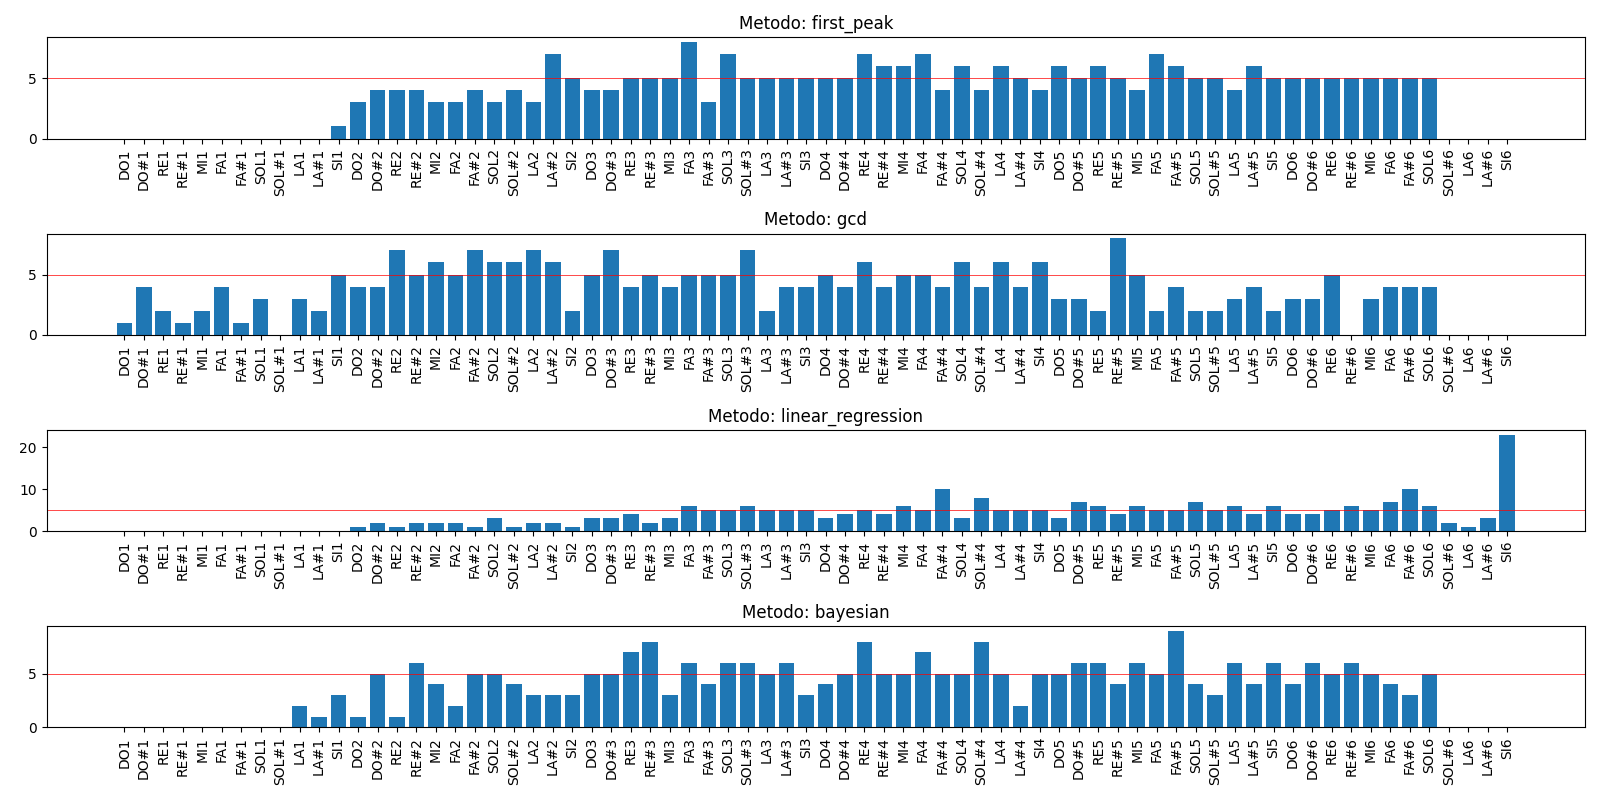

In [194]:
ordered_notes = list(note_freqs.keys())
fig, axs = plt.subplots(len(types), 1, figsize=(16, 8))

for i, method in enumerate(types):
    counts = [binned_results[method].count(note) for note in ordered_notes]
    axs[i].bar(np.arange(len(ordered_notes)), counts, width=0.8)
    axs[i].set_title(f"Metodo: {method}")
    axs[i].set_xticks(np.arange(len(ordered_notes)))
    axs[i].set_xticklabels(ordered_notes, rotation=90)
    axs[i].axhline(5, color='red', linewidth=0.5)

plt.tight_layout()
plt.show()
